#### Spam SMS 분류
: SMS 메세지가 스팸인지 아닌지를 예측

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import zipfile
import requests
from io import BytesIO

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 데이터 로드 : SMS Spam Collection Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
response = requests.get(url)
with zipfile.ZipFile(BytesIO(response.content)) as zip_ref:
    with zip_ref.open("SMSSpamCollection") as file: # zip 안에 있는 SMS 어쩌구 뽑아내는 거 
        data = pd.read_csv(file, sep='\t', names=['label','message'])

In [3]:
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
data.label.unique()

<StringArray>
['ham', 'spam']
Length: 2, dtype: str

In [5]:
# 데이터 전처리 
# 라벨 인코더 : 'ham' -> 0, 'spam' -> 1 / 햄이 먼저 있어서 0번이다

label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])
data.head()



,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# 텍스트 토근화
tokenizer = Tokenizer(num_words=5000) # 다 가져오지 않고 5000개만 쓰겠다 
tokenizer.fit_on_texts(data['message']) # 어떤 문자가 들어있는지 학습하는거 
X = tokenizer.texts_to_sequences(data['message'])

In [7]:
print(X)

[[49, 471, 4436, 842, 755, 658, 64, 8, 1327, 88, 123, 351, 1328, 148, 2997, 1329, 67, 58, 4437, 144], [46, 336, 1499, 472, 6, 1940], [47, 489, 8, 19, 4, 797, 901, 2, 176, 1941, 1105, 659, 1942, 2331, 261, 2332, 71, 1941, 2, 1943, 2, 337, 489, 555, 960, 73, 391, 174, 660, 392, 2998], [6, 248, 150, 23, 382, 2999, 6, 139, 154, 57, 150], [1024, 1, 98, 108, 69, 490, 2, 961, 69, 1944, 221, 112, 473], [798, 129, 67, 1690, 145, 109, 158, 1945, 21, 7, 38, 338, 89, 902, 55, 116, 414, 3, 44, 12, 14, 86, 1946, 46, 365, 960, 4438, 2, 68, 323, 232, 2, 3000], [210, 11, 633, 9, 25, 55, 2, 383, 36, 10, 110, 718, 10, 55, 4439, 4440], [72, 235, 13, 1204, 2333, 2334, 1947, 2335, 2336, 2337, 799, 118, 109, 609, 72, 13, 1025, 12, 51, 1691, 843, 393, 2, 1106, 13, 249, 1025], [719, 72, 4, 844, 441, 236, 3, 17, 109, 442, 2, 3001, 1330, 151, 962, 2, 127, 16, 3002, 127, 415, 3003, 516, 963, 581, 64], [136, 13, 97, 686, 1026, 26, 133, 6, 82, 1205, 2, 491, 2, 5, 324, 535, 903, 36, 339, 12, 47, 16, 5, 97, 491, 243,

In [8]:
# Padding 
X = pad_sequences(X, maxlen=200)

In [9]:
y = data['label'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [10]:
-ㅠㅓ

NameError: name 'ᅲᅥ' is not defined

In [ ]:
# 훈련 및 테스트 분리 
# LSTM 모델 생성 및 훈련
# 모델 평가

In [11]:
from sklearn.model_selection import train_test_split

train_input,val_input,train_target,val_target = train_test_split(
                                                        X,
                                                        y,
                                                        test_size=0.2,
                                                        random_state=42

)

In [15]:
# 크기 확인
train_input.shape
train_target.shape

(4457,)

In [18]:
# 패딩 되어 있는지 확인
print(train_input[200])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0   63   88  293   82    5  389  255    8   92
  166 1237   63  553  200    2  662  293    7 1237  293  553  200    2
  662 

---
### LSTM 신경망 모델 만들기

In [22]:
from tensorflow import keras

model = keras.Sequential()
model.add(keras.layers.Embedding(5000, 16))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.build(input_shape=(None, 200))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 16)        │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,809 (315.66 KB)

 Trainable params: 80,809 (315.66 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 16)        │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,809 (315.66 KB)

 Trainable params: 80,809 (315.66 KB)

 Non-trainable params: 0 (0.00 B)

#### LSTM 신경망 훈련하기

In [24]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(
    optimizer=rmsprop,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best-lstm-model.keras")
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)


history = model.fit(
            train_input,
            train_target,
            epochs=100, # early_stopping 있어서 괜찮다
            batch_size=64,
            validation_data=(val_input, val_target),
            callbacks=[checkpoint_cb, early_stopping_cb]
)


Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8409 - loss: 0.6643 - val_accuracy: 0.8664 - val_loss: 0.6324
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8658 - loss: 0.5960 - val_accuracy: 0.8664 - val_loss: 0.5525
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8658 - loss: 0.5147 - val_accuracy: 0.8664 - val_loss: 0.4732
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8658 - loss: 0.4415 - val_accuracy: 0.8664 - val_loss: 0.4073
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8658 - loss: 0.3838 - val_accuracy: 0.8664 - val_loss: 0.3591
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8658 - loss: 0.3438 - val_accuracy: 0.8664 - val_loss: 0.3289
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8658 - loss: 0.3189 - val_accuracy: 0.8664 - val_loss: 0.3091
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8658 - loss: 0.3007 - val_accuracy: 0.

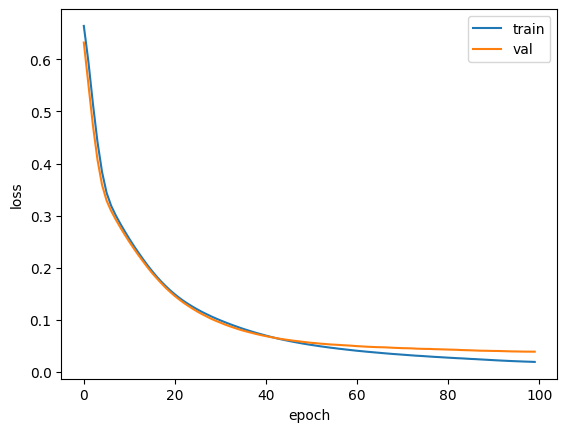

In [26]:
import matplotlib.pyplot as plt
# 손실 그래프 확인
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()